In [1]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from random import shuffle

torch.manual_seed(0)

In [ ]:
class TicTacToe:
    def __init__(self):
        """
            initalizes the TicTacToe class
        """
        self.row_count = 3
        self.column_count = 3
        self.action_size = self.row_count * self.column_count
        
    def __repr__(self):
        return "TicTacToe"
        
    def get_initial_state(self):
        """
            creates a numpy matrix of row*column 0's which represent untouched cells on the board
            
            ### Parameters: 
                    - None
                    
            ### Returns: 
                    - numpy array
        """
        return np.zeros((self.row_count, self.column_count))
    
    def get_next_state(self, state, action, player):
        """
            extracts the position of the players marker on the board (row, column) from action and saves it in state
    
            ### Parameters: 
                    - state (int[3][3]): a matrix of 3x3 that represents the state of the game with the posistion of each piece of both players
                    - action (int): an integer that represents the position of the player marker as {row*3 + column}
                    - player (int): a unique integer flag representing a player and their piece on the board
                    
            ### Returns: 
                    - state (int[3][3])
        """
        row = action // self.column_count       # 8 will mean row 3, 4 will mean row 2 etc etc
        column = action % self.column_count     # 3 will mean oclumn 1, 4 will mean column 2 etc etc
        state[row,column] = player              # places the piece of the player on the board
        return state
    
    def get_valid_moves(self,state):
        """
            returns all played and unplayed cell in the matrix/board 
    
            ### Parameters: 
                    - state (int[3][3]): a matrix of 3x3 that represents the state of the game with the posistion of each piece of both players
                    
            ### Returns: 
                    - 1D boolean array of lenght 9 converted to integer representing occupied and unoccupied positions on the board, where 0 is invalid (occupied) cell and 1 is valid (occupied) cell.
        """
        return (state.reshape(-1) == 0).astype(np.uint8)
    
    def check_win(self, state, action):
        """
            Checks if a player has won or not. Sums the pieces in horizontal and diagonal lines to see if they are equal to 3 (or -3).
    
            ### Parameters: 
                    - state (int[3][3]): a matrix of 3x3 that represents the state of the game with the posistion of each piece of both players
                    - action (int): an integer that represents the position of the player marker as {row*3 + column}
                    
            ### Returns: 
                    - a boolean (T/F)
        """
        if action == None:  # special case for the root node because it is initialised with action set to None and we dont want out code erroring cause of that
            return False
        
        row = action // self.column_count
        column = action % self.column_count
        player = state[row, column]
        
        return (
            np.sum(state[row, :]) == player * self.column_count                     # checks all rows for a straight line of pieces
            or np.sum(state[:, column]) == player * self.row_count                  # checks all columns for a strain line of pieces
            or np.sum(np.diag(state)) == player * self.row_count                    # checks left to right diagonal for a straight line of pieces
            or np.sum(np.diag(np.flip(state, axis=0))) == player * self.row_count   # checss right to left diagonal for a straight line of pieces
        )
    
    def get_value_and_terminated(self, state, action):
        """
            returns (int, bool) 1 if player has won and 0 otherwise, and True if game terminated and False otherwise 
        """
        if self.check_win(state, action):
            return 1, True
        if np.sum(self.get_valid_moves(state)) == 0:
            return 0, True
        return 0, False
    
    def get_opponent(self, player):
        """for switching between the two players"""
        return -player
    
    def get_opponent_value(self, value):
        """uses player 1 score to evaluate player 2 score by simply returning the negative of player 1 score as TicTacToe is a zero sum game"""
        return -value
    
    def change_perspective(self, state, player):
        """flips the board and shows it from the perspective of the second player"""
        return state*player
    
    def get_encoded_state(self, states):
        """
            One hot encoding of the state.
            
            ### Parameters:
                    - states (np.array([batch_size, 3, 3])): batched (for parallel play) states 
                    
            ### Returns:
                    - encoded_state (np.array([batch_size, 3, 3, 3])): a numpy tensor of batched hot encoded state of positions of -1, 0, 1.
        """
        encoded_state = np.stack(
            (states==-1, states==0, states==1)
        ).astype(np.float32)
        
        if len(states.shape) == 3:
            encoded_state = np.swapaxes(encoded_state, 0, 1)   # what the sigma, we do this for multiple batches but i dont get why. Video 3:34:45
        return encoded_state

In [ ]:
class ResNet(nn.Module):
    """"
    Resnet neural network class
    
    ### Parameters: 
            - game: the class of game we want the model to train on 
            - num_resBlocks (int)
            - num_hidden
            - device
            
    ### Returns:
            - policy (torch.tensor([batch_size, action_size])): batched up policies, of action scores
            - value (torch.tensor([batch_size, 1])): value of a state in the batched state 
    """
    def __init__(self, game:TicTacToe, num_resBlocks, num_hidden, device):
        super().__init__()
        
        self.device = device
        self.startBlock = nn.Sequential(
            nn.Conv2d(3, num_hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_hidden),
            nn.ReLU(),
        )
        
        self.backBone = nn.ModuleList(
            [ResBlock(num_hidden) for i in range(num_resBlocks)]
        )
        
        self.policyHead = nn.Sequential(
            nn.Conv2d(num_hidden, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*game.row_count*game.column_count, game.action_size)
        )
        
        self.valueHead = nn.Sequential(
            nn.Conv2d(num_hidden,  3, kernel_size=3, padding=1),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3*game.row_count*game.column_count, 1),
            nn.Tanh()
        )
        self.to(device)
        
    def forward(self, x):
        x = self.startBlock(x)
        for resBlock in self.backBone:
            x = resBlock(x)
        policy = self.policyHead(x)
        value = self.valueHead(x)
        return policy, value
        

class ResBlock(nn.Module):
    def __init__(self, num_hidden):
        super().__init__()
        self.conv1 = nn.Conv2d(num_hidden, num_hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_hidden)
        self.conv2 = nn.Conv2d(num_hidden, num_hidden, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_hidden)
        
    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x

[[ 0.  0.  1.]
 [ 0.  0.  0.]
 [ 0. -1.  0.]]
encoded state:
 [[[0. 0. 0.]
  [0. 0. 0.]
  [0. 1. 0.]]

 [[1. 1. 0.]
  [1. 1. 1.]
  [1. 0. 1.]]

 [[0. 0. 1.]
  [0. 0. 0.]
  [0. 0. 0.]]]
tensor state:
 tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 1., 0.]],

         [[1., 1., 0.],
          [1., 1., 1.],
          [1., 0., 1.]],

         [[0., 0., 1.],
          [0., 0., 0.],
          [0., 0., 0.]]]])
value : -0.41660529375076294
policy : [0.10902689 0.07589045 0.15256834 0.14958978 0.14718556 0.10360715
 0.08884433 0.06014102 0.11314645]


C:\Users\jasje\AppData\Local\Temp\ipykernel_13468\1348385788.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model_2.pt'))


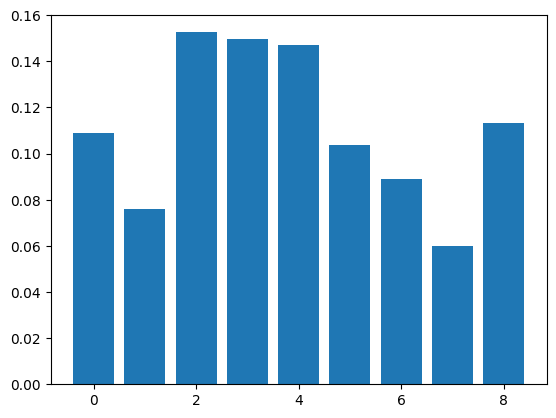

In [4]:
import matplotlib.pyplot as plt

tictactoe = TicTacToe()
state = tictactoe.get_initial_state()
state = tictactoe.get_next_state(state, 2, 1)
state = tictactoe.get_next_state(state, 7, -1)

print(state)

encoded_state = tictactoe.get_encoded_state(state)
print("encoded state:\n", encoded_state)

tensor_state = torch.tensor(encoded_state).unsqueeze(0)  # basically added an extra squere bracket to create a batch
print("tensor state:\n", tensor_state)

model = ResNet(tictactoe, 4, 64, device=torch.device("cpu"))
model.load_state_dict(torch.load('model_2.pt'))
model.eval()
policy, value = model(tensor_state)
value = value.item()
policy = torch.softmax(policy, axis=1).squeeze(0).detach().cpu().numpy()  # removed that extra bracket to remove the batch axis
print(f"value : {value}\npolicy : {policy}")

plt.bar(range(tictactoe.action_size), policy)
plt.show()

In [ ]:
class Node:
    def __init__(self, game:TicTacToe, args, state, parent=None, action_taken=None, prior=0, visit_count=0):
        """initializes the Node class"""
        self.game = game 
        self.args = args
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.prior = prior
        
        self.children = []
        
        self.visit_count = visit_count
        self.value_sum = 0
        
    def is_fully_expanded(self):
        """checks if all states possible from a node (except that leaf/terminal node) have been visited or not"""
        return len(self.children) > 0
    
    def select(self):
        """determines which node to explore next using the UCB values of the nodes."""
        best_child = None
        best_ucb = -np.inf
        
        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb>best_ucb:
                best_child = child 
                best_ucb = ucb
            
        return best_child
    
    def get_ucb(self, child: 'Node'):
        """
            calculates the average UCB value normalised to the range [0,1] and inverted so that it is from the perspective of the player who is about to make a move (and not the one who just made the move)
            
            ### Parameters:
                    - child: child node of the current node
                    
            ### Returns:
                    - UCB value
        """
        if child.visit_count==0:
            q_value=0
        else:
            q_value = 1 - ((child.value_sum/child.visit_count) + 1) / 2  # what teh sigma. author says its possible to have negative value sum from -1 to 1 so we add one and divide by 2 so this turns into a probability and we subtract it all from 1 because child is of antagonist whereas parent which actually usues the UCB is of the protagonist
        return q_value + self.args['C'] * (math.sqrt(self.visit_count/(child.visit_count+1))) * child.prior
    
    def expand(self, policy):
        """creates a new node for a valid move in expandable_moves()"""
        for action , prob in enumerate(policy):
            if prob>0:
                child_state = self.state.copy()
                child_state = self.game.get_next_state(child_state, action, 1)
                child_state = self.game.change_perspective(child_state, player=-1)
                
                child = Node(self.game, self.args, child_state, self, action, prob)
                self.children.append(child)
        return child
            
    def backpropagate(self, value):
        """for updating the value estimates of the nodes in the search tree.

        ### Parameters:
                - value (int): 1 for win, 0 for draw, -1 for loss
        """
        self.value_sum += value
        self.visit_count += 1
        
        value = self.game.get_opponent_value(value)
        if self.parent is not None :
            self.parent.backpropagate(value)

In [ ]:
Node.select

In [ ]:
class MCTSParallel:  # This is not really parallel MCTS, more like batched MCTS. Not truly parallel as we are using a for loop for multiple games, maybe we can improve on that later. 
    def __init__(self, game:TicTacToe, args, model:ResNet):
        self.game = game
        self.args = args
        self.model = model
    
    @torch.no_grad()  # basically the same as `with torch.no_grad():`
    def search(self, states, spGames):
        """
        Performs Monte Carlo Tree Search (MCTS) simulations in parallel for a batch of game states.

        This function iterates through a specified number of searches, selecting, expanding,
        evaluating, and backpropagating values to improve policy and value estimates for
        the given game states.

        Parameters:
            states (np.array): A NumPy array representing a batch of game states.
                Shape: (batch_size, row_count, column_count)
            spGames (list[SPG]): A list of SPG (Self-Play Game) objects, each containing
                the game state, MCTS tree, and other game-related information for a
                game being played in parallel.

        Returns:
            None. The function modifies the MCTS trees within the spGames objects in place.
        """
        
        # explanation of the function is as follows:
        """this function takes a node, treats it as root node, ie temporarily discards all nodes above it, 
        then expands on the node (one level in one iteration) and picks the best child (if the node is fully expanded)
        in that same iteration and continues till the leaf root node is reached and backpropagate. There 
        are 2 triggerts for backpropagation
        
        Backpropagation is triggered only after a node has been evaluated. This happens in these two scenarios:
            - Terminal Node: If the selected node is a terminal node (win, loss, or draw), the game outcome is used as the evaluation value, and backpropagation occurs.
            - Non-Fully Expanded Node: If the selected node is not fully expanded, it is expanded, the neural network evaluates the new node, and then backpropagation occurs.
        """
        policy, _ = self.model(  # the blank wouldve been policy but we dont need it 
                torch.tensor(self.game.get_encoded_state(states), device=self.model.device)  # we no longer need to call unsqueeze here because we now have a batch
            )
        policy = torch.softmax(policy, axis=1).cpu().numpy()  # again we dont squeeze here because now we need the batches
        
        policy = (1-self.args['dirichlet_epsilon'])*policy + self.args['dirichlet_epsilon']*np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size, size=policy.shape[0])  # weve speicfied the sahpe of noise has to be equal to shape of policy with shape attribute
        
        for i, spg in enumerate(spGames):
            spg_policy = policy[i]
            valid_moves = self.game.get_valid_moves(states[i])
            spg_policy *= valid_moves
            spg_policy /= np.sum(spg_policy)
            
            # define root
            spg.root = Node(self.game, self.args, states[i], visit_count=1)
            spg.root.expand(spg_policy)
        
        # 1. selection
        for search in range(self.args['num_searches']):
            for spg in spGames:
                spg.node = None
                node = spg.root
                
                while node.is_fully_expanded():
                    node = node.select()
                    
                value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)  # if the result is that the player has won here then it is the antagonist and not the protagonist. What the sigma to that, i dont know how that is
                # if we want to read this value here from the node's/antagonist's perspective then we have to change it around
                value = self.game.get_opponent_value(value)
                
                if is_terminal:
                    # 4. backpropagation
                    node.backpropagate(value)
                else:
                    spg.node = node
            
            expandable_spGames = [mappingIdx for mappingIdx in range(len(spGames)) if spGames[mappingIdx].node is not None]
            if len(expandable_spGames)>0:
                states = np.stack([spGames[mappingIdx].node.state for mappingIdx in expandable_spGames])
                policy, value = self.model(
                    torch.tensor(self.game.get_encoded_state(states), device=self.model.device)
                )
                policy = torch.softmax(policy, axis=1).cpu().numpy()
                
            for i, mappingIdx in enumerate (expandable_spGames):
                node = spGames[mappingIdx].node
                spg_policy, spg_value = policy[i], value[i]
                valid_moves = self.game.get_valid_moves(node.state)
                spg_policy *= valid_moves  # all illegal moves will have a policy of 0
                spg_policy /= np.sum(spg_policy)
                
                node = node.expand(spg_policy)
                node.backpropagate(spg_value)

In [ ]:
class SPG:  # SPG stands for self play game
    """
    Represents a single self-play game, containing its state, memory, and MCTS tree.

    This class encapsulates all the information needed for a self-play game, including
    the current game state, the memory of the game (for training data), and the
    Monte Carlo Tree Search (MCTS) tree used for move selection.

    ### Attributes:
            - state (np.array): The current state of the game board.
            - memory (list): A list of tuples, where each tuple contains:
                - The encoded game state (np.array).
                - The policy targets (action probabilities) (np.array).
                - The player's perspective (int).
            - root (Node): The root node of the MCTS tree for this game.
            - node (Node): The currently selected node in the MCTS tree.
    """
    def __init__(self, game: TicTacToe):
        self.state = game.get_initial_state()
        self.memory = []
        self.root = None
        self.node = None

In [ ]:
class AlphaZeroParallel:
    def __init__(self, model: ResNet, optimizer: torch.optim, game: TicTacToe, args):
        self.model=model
        self.optimizer=optimizer
        self.game=game
        self.args=args
        self.mcts = MCTSParallel(game, args, model)
        
    def selfPlay(self):
        """
        Generates training data through parallel self-play games guided by MCTS.

        This function simulates multiple TicTacToe games concurrently, using the current
        neural network model to guide the Monte Carlo Tree Search (MCTS) for move selection.
        For each game, it performs one move per iteration, selects the best move based on
        MCTS visit counts, updates the game states, and stores the game history as training data.

        The training data consists of game states, policy targets (action probabilities),
        and game outcomes. This data is then used to train the neural network model to
        improve its policy and value predictions.

        ### Returns:
            - list: A list of tuples, where each tuple contains:
                - The encoded game state (np.array).
                - The policy targets (action probabilities) (np.array).
                - The game outcome (int).
        """
        
        return_memory = []
        player = 1
        spGames = [SPG(self.game) for spg in range(self.args['num_parallel_games'])]

        
        while len(spGames)>0:
            states = np.stack([spg.state for spg in spGames])
            
            neutral_states = self.game.change_perspective(states, player)
            self.mcts.search(neutral_states, spGames)
            
            for i in range(len(spGames))[::-1]:  # flipping range of self play games for perfect allignment
                spg = spGames[i]
                action_probs = np.zeros(self.game.action_size)
                for child in spg.root.children:
                    action_probs[child.action_taken] = child.visit_count
                action_probs /= np.sum(action_probs)
                
                spg.memory.append((spg.root.state, action_probs, player))
                
                temperature_action_probs = action_probs**(1/self.args['temperature'])  # adds randomness/noise, at temperature going to infinity the choice is almost random hence exploratory and at tempreature 1 the choice is exploitation
                action = np.random.choice(self.game.action_size, p=action_probs)
                
                spg.state = self.game.get_next_state(spg.state, action, player)
                
                value, is_terminal = self.game.get_value_and_terminated(spg.state, action)
                
                if is_terminal:
                    for hist_neutral_state, hist_action_probs, hist_player in spg.memory:
                        hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)  # we want to recieve value if the player we started with has won (1 started and won) and otherwise -value if player we started with lsot (1 started and lost)
                        return_memory.append((
                            self.game.get_encoded_state(hist_neutral_state),
                            hist_action_probs,
                            hist_outcome
                        ))

                    del spGames[i]
                    
            player = self.game.get_opponent(player)
        
        return return_memory
    
    def train(self, memory):
        """
        Trains the neural network model using the provided training data.

        This function iterates through the training data in batches, calculates the policy and
        value losses, combines them, and updates the model's weights using gradient descent.

        ### Args:
                - memory (list): A list of tuples, where each tuple contains:
                    - The encoded game state (np.array).
                    - The policy targets (action probabilities) (np.array).
                    - The game outcome (int).

        ### Returns:
                - None. The function updates the model's weights in place.
    """
        
        shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']):
            sample = memory[batchIdx:batchIdx+self.args['batch_size']]
            state, policy_targets, value_targets = zip(*sample)
            
            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)
            
            state = torch.tensor(state, dtype=torch.float32, device=self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype=torch.float32, device=self.model.device)
            value_targets = torch.tensor(value_targets, dtype=torch.float32, device=self.model.device)
            
            out_policy, out_value = self.model(state)
            
            policy_loss = F.cross_entropy(out_policy, policy_targets)
            value_loss = F.mse_loss(out_value, value_targets)
            loss = policy_loss+value_loss  
            # ⚠️⚠️⚠️ simply adding up loss can cause info loss. One: Bias due to one loss being bigger than the other as one is MSE and other is Cross entropy. Two: Adding rather than using them seperately
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
    
    def learn(self):
        """integrates the selfPlay and train function in a loop for num_iterations"""
        for iteration in range(self.args['num_iterations']):
            memory = []
            
            self.model.eval()
            for selfPlay_iteration in tqdm(range(self.args['num_selfPlay_iterations'] // self.args['num_parallel_games'])):
                memory += self.selfPlay()
                
            self.model.train()
            for epoch in tqdm(range(self.args['num_epochs'])):
                self.train(memory)
            
            torch.save(self.model.state_dict(), f"model_{iteration}.pt")
            torch.save(self.optimizer.state_dict(), f"optimizer_{iteration}.pt")

In [10]:
tictactoe = TicTacToe()
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
model = ResNet(tictactoe, 4, 64, device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
args = {
    'C':2,
    'num_searches':10,
    'num_iterations':8,
    'num_selfPlay_iterations':100,
    'num_parallel_games':100,
    'num_epochs':4,
    'batch_size':64,
    'temperature':1.25,
    'dirichlet_epsilon':0.25,
    'dirichlet_alpha':0.3
}

alphazero = AlphaZeroParallel(model, optimizer, tictactoe, args)
alphazero.learn()

  0%|          | 0/1 [00:05<?, ?it/s]

Unexpected exception formatting exception. Falling back to standard exception



Traceback (most recent call last):
  File "c:\Users\jasje\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\jasje\AppData\Local\Temp\ipykernel_23692\1554331785.py", line 19, in <module>
    alphazero.learn()
  File "C:\Users\jasje\AppData\Local\Temp\ipykernel_23692\1080242901.py", line 80, in learn
    memory += self.selfPlay()
              ^^^^^^^^^^^^^^^
  File "C:\Users\jasje\AppData\Local\Temp\ipykernel_23692\1080242901.py", line 19, in selfPlay
    self.mcts.search(neutral_states, spGames)
  File "c:\Users\jasje\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\_contextlib.py", line 116, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jasje\AppData\Local\Temp\ipykernel_23692\2620354428.py", line 34, in search
    node = node.select()
           ^^^^^^^^^^^^^
  File "C:\U

In [8]:
tictactoe = TicTacToe()
player = 1

args = {
    'C' : 2, 
    'num_searches' : 1000
}

model = ResNet(tictactoe, 4, 64)
model.eval()

mcts = MCTS(tictactoe, args, model)
state = tictactoe.get_initial_state()

while True:
    print(state)
    
    if player ==1:
        valid_moves = tictactoe.get_valid_moves(state)
        print(f"valid_moves : {[i for i in range(tictactoe.action_size) if valid_moves[i]==1]}")
        action = int(input(f"{player}: "))
        
        if valid_moves[action] == 0:
            print("action not valid")
            continue
    
    else:
        neutral_state = tictactoe.change_perspective(state, player)
        mcts_probs = mcts.search(neutral_state)
        action = np.argmax(mcts_probs)
    
    state = tictactoe.get_next_state(state, action, player)
    
    value, is_terminal = tictactoe.get_value_and_terminated(state, action)
    
    if is_terminal:
        print(state)
        if value == 1:
            print(f"{player} won")
        else:
            print("draw")
        break
    
    player = tictactoe.get_opponent(player)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
valid_moves : [0, 1, 2, 3, 4, 5, 6, 7, 8]
[[1. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[ 1.  0. -1.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]]
valid_moves : [1, 3, 4, 5, 6, 7, 8]
[[ 1.  0. -1.]
 [ 0.  0.  0.]
 [ 0.  0.  1.]]
[[ 1.  0. -1.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
valid_moves : [1, 3, 5, 6, 7]
[[ 1.  0. -1.]
 [ 0. -1.  0.]
 [ 1.  0.  1.]]
[[ 1.  0. -1.]
 [ 0. -1.  0.]
 [ 1. -1.  1.]]
valid_moves : [1, 3, 5]
action not valid
[[ 1.  0. -1.]
 [ 0. -1.  0.]
 [ 1. -1.  1.]]
valid_moves : [1, 3, 5]
[[ 1.  0. -1.]
 [ 1. -1.  0.]
 [ 1. -1.  1.]]
1 won
